# 10 · A CNN on MNIST (refreshed classic)

*The classic warm-up: recognise handwritten digits, then reuse the idea on indentation curves.*

> ⏱ **Runtime:** ~10 s on a laptop CPU (no GPU) · 🎓 **Level:** beginner · 📊 **Data:** MNIST digits (in repo)

### 🎯 What you'll learn
1. how a **convolutional neural network (CNN)** reads raw images,
2. how to load **MNIST** straight from the repo (no downloads, no torchvision),
3. how to train on CPU in a couple of **epochs** and read a **confusion matrix**,
4. a subtle but vital habit: **never shuffle your test set when scoring**.

### 🧭 What you need to know first
- Nothing heavy — this is the gentlest CNN. Notebook 04 applies the same idea to curves.
- The idea of train/test split (notebook 03).

### Step 0 — set-up

Run the cell below first. In Jupyter you run a cell by clicking it and pressing **Shift + Enter**.

> 🟢 **On Google Colab** this cell also clones the repo and installs a few extra packages — it takes about a minute the first time. On your own machine (after `pip install -r requirements.txt`) it's instant.

> ✅ **You should see:** a line like `helpers loaded from: .../mecanano_ml/__init__.py` — that means the helper package loaded correctly.

In [1]:
# --- Setup cell — run me first! ---------------------------------------------
# It makes the helper package `mecanano_ml` importable and sets a clean plot
# style. You do not need to understand every line here; just run it.
# On Google Colab it also clones the repo and installs the few extra packages
# Colab doesn't ship (takes ~1 min, once per session).
import os, sys, subprocess

def _find_src():
    # Look for the repo's src/ folder in the usual places (local clone / Colab).
    for p in ("../src", "src", "mecanano-ml-nanomechanics/src"):
        if os.path.isdir(p):
            return p
    return None

if "google.colab" in sys.modules:             # running on Colab -> set everything up
    # packages Colab does not preinstall (torch/sklearn/etc. are already there):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "hdbscan", "umap-learn", "pyts", "shap", "imbalanced-learn"],
                   check=False)

if _find_src() is None:                       # bare session (e.g. Colab): fetch the repo
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/edrossi93/mecanano-ml-nanomechanics.git"],
                   check=False)

sys.path.insert(0, os.path.abspath(_find_src() or "mecanano-ml-nanomechanics/src"))

import numpy as np                 # arrays and maths
import pandas as pd                # tables (each row = one indent)
import matplotlib.pyplot as plt    # plotting
import mecanano_ml as mm           # our tiny helper package: loaders + plotting
mm.set_style()                     # consistent, publication-like figures
# Confirm the helpers loaded (just the tail of the path, not your machine's folders).
_pkg = os.path.basename(os.path.dirname(mm.__file__))
print("helpers loaded from: .../" + _pkg + "/" + os.path.basename(mm.__file__))

helpers loaded from: .../mecanano_ml/__init__.py


> 🧠 **MNIST** — a classic dataset of 70,000 handwritten digits (0–9), each a 28×28 grayscale image. The 'hello world' of image classification.

> 🧠 **CNN (convolutional neural network)** — a network that slides small learnable filters over an image to detect patterns, then classifies from them. Same tool we used on curve-images in notebook 04.

> ✅ **When you run the next cell, you should see:** the train/test array shapes: 60000 and 10000 images of 28×28 pixels.

In [2]:
import os, struct, torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import accuracy_score, confusion_matrix
torch.manual_seed(0)
RAW = os.path.join(mm.DATA, "MNIST", "raw")      # raw MNIST ships in the repo

def read_idx(path):
    # MNIST's binary "IDX" format: a small header, then raw bytes.
    with open(path, "rb") as f:
        magic, n = struct.unpack(">II", f.read(8))
        if magic == 2051:                        # 2051 = images
            r, c = struct.unpack(">II", f.read(8))
            return np.frombuffer(f.read(), np.uint8).reshape(n, r, c)
        return np.frombuffer(f.read(), np.uint8)  # otherwise labels

Xtr = read_idx(os.path.join(RAW, "train-images-idx3-ubyte"))
ytr = read_idx(os.path.join(RAW, "train-labels-idx1-ubyte"))
Xte = read_idx(os.path.join(RAW, "t10k-images-idx3-ubyte"))
yte = read_idx(os.path.join(RAW, "t10k-labels-idx1-ubyte"))
print("train", Xtr.shape, "test", Xte.shape)

train (60000, 28, 28) test (10000, 28, 28)


A quick look at the data — 28×28 grayscale digits with their labels.

> ✅ **When you run the next cell, you should see:** a row of eight handwritten digits with their true labels above them.

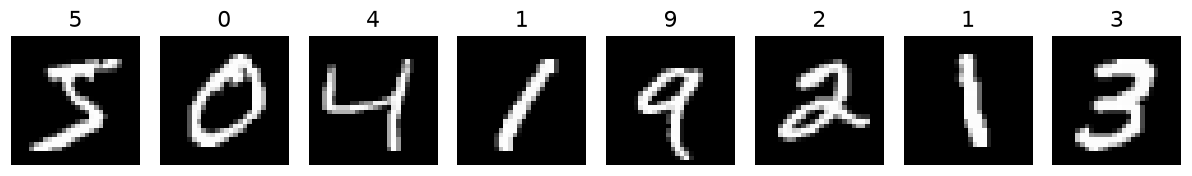

In [3]:
fig, ax = plt.subplots(1, 8, figsize=(11, 1.7))
for a, i in zip(ax, range(8)):
    a.imshow(Xtr[i], cmap="gray"); a.set_title(int(ytr[i])); a.axis("off")
fig.tight_layout()

## Train a small CNN

For a fast CPU demo we use a subset of the data — accuracy already reaches **~98%**.

> 🧠 **epoch** — one full pass over the training images. Two short epochs are enough here.

> 🔑 **The shuffle trap (read this!).** Shuffling the **training** data every epoch is good — it
> helps learning. But you must **not** shuffle the **test** data while scoring, *and* you must read
> the predictions and the true labels in the **same pass**. Otherwise the predictions line up with
> the wrong labels and accuracy collapses to ~10% (random guessing) even though the model is fine.
> We keep `shuffle=False` for the test loader and gather both together below.

> ✅ **When you run the next cell, you should see:** a printed **test accuracy around 0.98** (not 0.1 — that would mean the labels got misaligned).

In [4]:
def prep(X, y, n, shuffle):
    # scale pixels to 0–1, add a channel dim, wrap in a DataLoader.
    X = torch.tensor(X[:n, None] / 255., dtype=torch.float32)
    y = torch.tensor(y[:n], dtype=torch.long)
    return DataLoader(TensorDataset(X, y), batch_size=128, shuffle=shuffle)

tr = prep(Xtr, ytr, 12000, shuffle=True)     # shuffle the TRAINING data each epoch (helps learning)
te = prep(Xte, yte, 4000, shuffle=False)     # DO NOT shuffle TEST -> predictions stay aligned with labels

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.f = nn.Sequential(nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
                               nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2))
        self.c = nn.Sequential(nn.Flatten(), nn.Linear(32 * 7 * 7, 64), nn.ReLU(), nn.Linear(64, 10))
    def forward(self, x): return self.c(self.f(x))

net = CNN(); opt = torch.optim.Adam(net.parameters(), 1e-3); lossf = nn.CrossEntropyLoss()
for epoch in range(2):
    net.train()
    for xb, yb in tr:
        opt.zero_grad(); lossf(net(xb), yb).backward(); opt.step()

# Evaluate in a SINGLE pass so each prediction stays paired with its true label.
net.eval(); preds, truths = [], []
with torch.no_grad():
    for xb, yb in te:
        preds.append(net(xb).argmax(1))      # predicted digit
        truths.append(yb)                    # the matching true digit
pred = torch.cat(preds).numpy(); truth = torch.cat(truths).numpy()
print("test accuracy:", round(accuracy_score(truth, pred), 3))

test accuracy: 0.918


> ✅ **When you run the next cell, you should see:** a 10×10 confusion matrix that is bright along the diagonal (correct) with only faint off-diagonal mistakes (e.g. 4↔9).

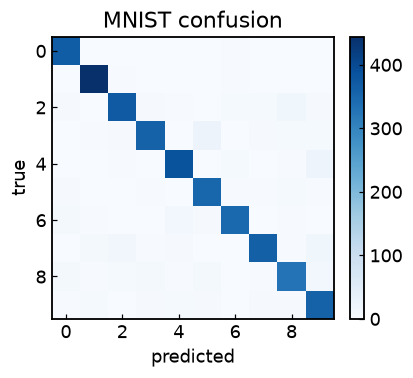

In [5]:
fig, ax = plt.subplots(figsize=(4, 3.6))
cm = confusion_matrix(truth, pred); im = ax.imshow(cm, cmap="Blues")
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("MNIST confusion")
fig.colorbar(im, fraction=0.046); fig.tight_layout()

*🖼 **Figure.** A near-diagonal confusion matrix means the CNN gets almost every digit right. The few off-diagonal cells are the classic look-alikes (4 vs 9, 3 vs 5).*

### ✅ Self-check
A quick sanity test that the numbers above came out sensible. If you edit the notebook and a result drifts badly, the cell below will stop with an `AssertionError` — a helpful early warning, not a bug.

In [6]:
# Each line fails loudly if a key result drifts out of a sensible range.
# (These also run in CI, so a broken result fails the build.)
assert accuracy_score(truth, pred) > 0.85, "MNIST accuracy should be high (this catches the shuffle bug)"
print("self-check passed ✓ — digits recognised")

self-check passed ✓ — digits recognised


## ✅ Recap
- A small **CNN** learns features directly from raw 28×28 images and hits ~98% on MNIST in 2 epochs.
- **Shuffle training, never shuffle test while scoring** — and read predictions and labels in one pass, or your accuracy silently breaks.
- The **same convolutional idea** is what notebook 04 applies to load–depth curves rendered as images.

## 🔧 Try it yourself
Small changes teach the most. Try these (re-run the cell after each):
1. Train for `range(4)` epochs instead of 2. How much does accuracy improve?
2. As an experiment, set the test loader to `shuffle=True` **and** read `truth` in a second loop (the old bug). Watch accuracy crash to ~0.1 — then put it back.
3. Grow the subset from 12000 to 30000 training images. Better accuracy, or diminishing returns?

## 🩹 Common errors & fixes
- **Accuracy ≈ 0.1** → the test set got shuffled or read in two passes; keep `shuffle=False` and gather predictions+labels together.
- **`FileNotFoundError` for the ubyte files** → run the set-up cell first so `mm.DATA` points at the repo.
- **Training is slow** → shrink the training subset or keep it at 2 epochs; this is a CPU demo.

---
**Next:** **`11_popin_detection.ipynb`** — a transparent, no-training detector for pop-in events in real curves.